In [21]:
##import assembly results

assembly_paths = {}

tsv_file = "/Users/ppxinyi/Documents/Assembly_review/30xL1-L3/Raven/L3.hpv_chains.tsv"   

with open(tsv_file, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split("\t", 1)
        if len(parts) < 2:
            continue

        contig = parts[0].strip()
        path = parts[1].strip()
        assembly_paths[contig] = path


def extract_minimal_hpv_chain(path):

    segments = [p.strip() for p in path.split("->")]

    hpv_idxs = [i for i,s in enumerate(segments) if "HPV" in s.upper()]

    if not hpv_idxs:
        return None

    first_hpv = min(hpv_idxs)
    last_hpv  = max(hpv_idxs)


    before_idx = first_hpv - 1 if first_hpv - 1 >= 0 else None


    after_idx = last_hpv + 1 if last_hpv + 1 < len(segments) else None

    selected = []

    if before_idx is not None:
        selected.append(segments[before_idx])

    # all HPV segments
    selected.extend(segments[first_hpv:last_hpv+1])

    if after_idx is not None:
        selected.append(segments[after_idx])

    return " -> ".join(selected)



assembly_paths_minimized = {}

for contig, path in assembly_paths.items():
    new_path = extract_minimal_hpv_chain(path)
    if new_path:   
        assembly_paths_minimized[contig] = new_path

import pprint
pprint.pprint(assembly_paths_minimized)



{'Utg756028': 'chr17_KI270857v1_alt:385449-390471(+) -> HPV16:4933-7906(+) -> '
              'HPV16:1-3526(+) -> chr3:65011017-74053720(+) -> '
              'chr3:74054039-74883226(+) -> HPV16:5731-7906(+) -> '
              'HPV16:1-930(+) -> chrX:97168404-97179422(+) -> '
              'HPV16:6335-7446(+)',
 'Utg756032': 'chr7:25425857-27213474(-) -> HPV16:1-3642(-) -> '
              'HPV16:7527-7906(-) -> HPV16:5505-7906(+) -> HPV16:1-4979(+) -> '
              'chr7:22501514-25425205(-)',
 'Utg756042': 'chr12:66057682-66733577(-) -> HPV16:1-4372(-) -> '
              'HPV16:5777-7906(-) -> chr17:36080097-36085610(-) -> '
              'chr17_KI270857v1_alt:314983-320495(-) -> '
              'chr17_KI270909v1_alt:34194-39707(-) -> HPV16:1-4372(-) -> '
              'HPV16:5779-7906(-) -> chr17:32074772-36085055(-)',
 'Utg756044': 'chr18:77037029-77653869(+) -> HPV16:5929-7906(+) -> '
              'HPV16:1-1128(+) -> chrX:97190312-97194237(+)',
 'Utg756068': 'chr6:156365950-1563

In [22]:
###good for L1-2-3
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import csv
import re
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
from collections import defaultdict
from itertools import product

import pandas as pd

# ============================================================
# Data structures
# ============================================================

@dataclass
class Segment:
    seq: str           # 'HPV', 'chr3', 'chr17', 'LIT', etc.
    start: int         # 1-based inclusive
    end: int           # 1-based inclusive
    strand: str        # '+' or '-'

    def length(self) -> int:
        return max(0, self.end - self.start + 1)

@dataclass
class ContigPath:
    name: str
    segments: List[Segment]

@dataclass
class TruthEvent:
    event_id: str
    chrom: str
    host_pos: int                 # pre-insertion anchor (for assignment)
    offset_bp: int = 0            # optional
    host_pos2: Optional[int] = None  # host_pos + offset_bp
    pattern_str: str = ""
    segments: List[Segment] = field(default_factory=list)

# ============================================================
# Parsing
# ============================================================

SEGMENT_RE = re.compile(r'(?P<name>[^:]+):(?P<coords>[^()]+)\((?P<strand>[+-])\)')
TOKEN_RE = re.compile(r'LIT:\d+|[^+]+\([+-]\)')  # truth uses '+' between tokens

def normalize_contig_segments(seglist: List[Segment]) -> List[Segment]:
    """
    If the first host segment (not HPV/LIT) is on '-' strand,
    reverse the whole path and flip strand (+ <-> -) for all segments.
    Coordinates remain in reference coordinate system.
    """
    host_idx = None
    for i, seg in enumerate(seglist):
        if seg.seq not in ("HPV", "LIT"):
            host_idx = i
            break

    if host_idx is None:
        return seglist

    if seglist[host_idx].strand != "-":
        return seglist

    new_list: List[Segment] = []
    for seg in reversed(seglist):
        if seg.strand == "+":
            new_strand = "-"
        elif seg.strand == "-":
            new_strand = "+"
        else:
            new_strand = seg.strand
        new_list.append(Segment(seq=seg.seq, start=seg.start, end=seg.end, strand=new_strand))
    return new_list

# def parse_segment_token(token: str) -> List[Segment]:
#     """
#     Parse a single token:
#       - HPV:2599-4572(+)
#       - HPV:4100-7906,1-3572(-)  (wrap-around, becomes two segments)
#       - chr17:36094082-36099602(+)
#       - LIT:5  (treated as 5000bp)
#     Returns a list of Segment (since HPV token may include multiple intervals).
#     NOTE: We DO NOT reorder HPV wrap-around segments here. HPV circular rotation
#           will be handled later in ordered alignment.
#     """
#     token = token.strip()

#     if token.startswith("LIT:"):
#         k = int(token.split(":")[1])
#         length = k * 1000
#         return [Segment(seq="LIT", start=1, end=length, strand="+")]

#     m = SEGMENT_RE.match(token)
#     if not m:
#         raise ValueError(f"Cannot parse segment token: {token}")

#     name = m.group("name")
#     coords_str = m.group("coords")
#     strand = m.group("strand")

#     segs: List[Segment] = []
#     for part in coords_str.split(","):
#         part = part.strip()
#         if not part:
#             continue
#         s_str, e_str = part.split("-")
#         s = int(s_str); e = int(e_str)
#         if e < s:
#             s, e = e, s
#         segs.append(Segment(seq=name, start=s, end=e, strand=strand))
#     return segs
HPV_LEN = 7906 
HPV_ALIASES = {
    "HPV", "HPV16", "HPV16REF", "HPV16REF|lcl|Human", "HPV16REF|lcl|Human", "HPV16REF|lcl|Human"
}

def norm_seq(name: str) -> str:
    name = name.strip()
    if name == "HPV" or name.startswith("HPV16") or "HPV" in name:
        return "HPV"
    return name
    
def parse_segment_token(token: str) -> List[Segment]:
    token = token.strip()

    if token.startswith("LIT:"):
        k = int(token.split(":")[1])
        length = k * 1000
        return [Segment(seq="LIT", start=1, end=length, strand="+")]

    m = SEGMENT_RE.match(token)
    if not m:
        raise ValueError(f"Cannot parse segment token: {token}")

    name = norm_seq(m.group("name"))
    coords_str = m.group("coords")
    strand = m.group("strand")

    segs: List[Segment] = []

    for part in coords_str.split(","):
        part = part.strip()
        if not part:
            continue
        s_str, e_str = part.split("-")
        s = int(s_str); e = int(e_str)

        if name == "HPV":
    
            if e < s:
                segs.append(Segment(seq="HPV", start=s, end=HPV_LEN, strand=strand))
                segs.append(Segment(seq="HPV", start=1, end=e, strand=strand))
            else:
                segs.append(Segment(seq="HPV", start=s, end=e, strand=strand))

        else:

            if e < s:
                s, e = e, s
            segs.append(Segment(seq=name, start=s, end=e, strand=strand))


    if name == "HPV" and strand == "-":
        segs = list(reversed(segs))

    return segs

def parse_truth_pattern(pattern: str) -> List[Segment]:
    segs: List[Segment] = []
    for tok in TOKEN_RE.findall(pattern):
        segs.extend(parse_segment_token(tok))
    return segs

def parse_assembly_path(path: str) -> List[Segment]:
    segs: List[Segment] = []
    for tok in path.split("->"):
        tok = tok.strip()
        if not tok:
            continue
        segs.extend(parse_segment_token(tok))
    return segs

# ============================================================
# Truth loading (offset optional)
# ============================================================

def _infer_offset_bp_from_row(row: Dict[str, str]) -> int:
    """
    Try to read an offset column (e.g. 651) to compute host_pos2.
    If not found, return 0.
    """
    candidates = ["offset_bp", "offset", "delta", "shift", "post_offset", "ins_offset", "del_len", "bias_bp", "bias"]
    for k in candidates:
        if k in row and row[k] not in ("", ".", None):
            try:
                return int(float(row[k]))
            except Exception:
                pass
    return 0

def load_truth_events(truth_tsv: str) -> Dict[str, TruthEvent]:
    """
    Requires columns: event_id, chrom, host_pos, hpv_path
    offset_bp is optional and will be inferred if a known column exists.
    """
    events: Dict[str, TruthEvent] = {}

    with open(truth_tsv, newline="") as f:
        reader = csv.DictReader(f, delimiter="\t")
        required_cols = {"event_id", "chrom", "host_pos", "hpv_path"}
        missing = required_cols - set(reader.fieldnames or [])
        if missing:
            raise ValueError(f"Truth file missing columns: {missing}")

        for row in reader:
            eid = row["event_id"]
            chrom = row["chrom"]
            host_pos = int(row["host_pos"])
            pattern_str = row["hpv_path"]

            offset_bp = _infer_offset_bp_from_row(row)
            host_pos2 = host_pos + offset_bp if offset_bp not in (0, None) else None

            segs = parse_truth_pattern(pattern_str)
            segs = normalize_contig_segments(segs)  # normalize truth direction too

            events[eid] = TruthEvent(
                event_id=eid,
                chrom=chrom,
                host_pos=host_pos,
                offset_bp=offset_bp,
                host_pos2=host_pos2,
                pattern_str=pattern_str,
                segments=segs
            )

    return events

def load_contig_paths_from_dict(path_dict: Dict[str, str]) -> Dict[str, ContigPath]:
    contigs: Dict[str, ContigPath] = {}
    for name, path_str in path_dict.items():
        segs = parse_assembly_path(path_str)
        segs = normalize_contig_segments(segs)
        contigs[name] = ContigPath(name=name, segments=segs)
    return contigs

# ============================================================
# Assignment using host anchors + pre/post truth anchors
# ============================================================

def get_all_host_anchors(seglist: List[Segment]) -> List[Tuple[str, int]]:
    """
    Return all host anchors adjacent to HPV:
      - host -> HPV : use host.end
      - HPV -> host : use host.start
    """
    anchors: List[Tuple[str, int]] = []
    for i, seg in enumerate(seglist):
        if seg.seq != "HPV":
            continue

        if i - 1 >= 0:
            left = seglist[i - 1]
            if left.seq not in ("HPV", "LIT"):
                anchors.append((left.seq, left.end))

        if i + 1 < len(seglist):
            right = seglist[i + 1]
            if right.seq not in ("HPV", "LIT"):
                anchors.append((right.seq, right.start))

    anchors = list(dict.fromkeys(anchors))
    return anchors

def best_truth_anchor(ev: TruthEvent, asm_pos: int) -> int:
    cands = [ev.host_pos]
    if ev.host_pos2 is not None:
        cands.append(ev.host_pos2)
    return min(cands, key=lambda p: abs(p - asm_pos))

def assign_contigs_to_events(
    contigs: Dict[str, ContigPath],
    events: Dict[str, TruthEvent],
    max_dist: int = 50_000
) -> Dict[str, List[ContigPath]]:
    by_event: Dict[str, List[ContigPath]] = defaultdict(list)

    events_by_chrom: Dict[str, List[TruthEvent]] = defaultdict(list)
    for ev in events.values():
        events_by_chrom[ev.chrom].append(ev)

    for ctg in contigs.values():
        anchors = get_all_host_anchors(ctg.segments)
        if not anchors:
            continue

        best_ev = None
        best_dist = None

        for chrom, anchor_pos in anchors:
            for ev in events_by_chrom.get(chrom, []):
                truth_anchor = best_truth_anchor(ev, anchor_pos)
                d = abs(truth_anchor - anchor_pos)
                if best_dist is None or d < best_dist:
                    best_dist = d
                    best_ev = ev

        if best_ev is not None and best_dist is not None and best_dist <= max_dist:
            by_event[best_ev.event_id].append(ctg)

    return by_event

# ============================================================
# Ordered overlap accuracy WITH HPV circular rotation
# ============================================================

def seg_overlap_bp(t: Segment, a: Segment) -> int:
    if t.seq != a.seq:
        return 0
    s = max(t.start, a.start)
    e = min(t.end, a.end)
    return max(0, e - s + 1)

def best_ordered_overlap_alignment(
    truth_segs: List[Segment],
    asm_segs: List[Segment],
    gap_penalty: int = 0,
    mismatch_penalty: int = 0,
    require_strand: bool = False
) -> List[Tuple[Optional[int], Optional[int]]]:
    """
    Ordered DP alignment maximizing total overlap bp under order constraint.
    """
    n, m = len(truth_segs), len(asm_segs)
    dp = [[0]*(m+1) for _ in range(n+1)]
    bt = [[None]*(m+1) for _ in range(n+1)]  # 'D','U','L'

    for i in range(1, n+1):
        dp[i][0] = dp[i-1][0] + gap_penalty
        bt[i][0] = 'U'
    for j in range(1, m+1):
        dp[0][j] = dp[0][j-1] + gap_penalty
        bt[0][j] = 'L'

    for i in range(1, n+1):
        t = truth_segs[i-1]
        for j in range(1, m+1):
            a = asm_segs[j-1]

            if t.seq != a.seq:
                ms = mismatch_penalty
            else:
                if require_strand and t.strand != a.strand:
                    ms = mismatch_penalty
                else:
                    ms = seg_overlap_bp(t, a)

            diag = dp[i-1][j-1] + ms
            up   = dp[i-1][j] + gap_penalty
            left = dp[i][j-1] + gap_penalty

            best = max(diag, up, left)
            dp[i][j] = best
            bt[i][j] = 'D' if best == diag else ('U' if best == up else 'L')

    aln: List[Tuple[Optional[int], Optional[int]]] = []
    i, j = n, m
    while i > 0 or j > 0:
        step = bt[i][j]
        if step == 'D':
            aln.append((i-1, j-1))
            i -= 1; j -= 1
        elif step == 'U':
            aln.append((i-1, None))
            i -= 1
        else:
            aln.append((None, j-1))
            j -= 1

    aln.reverse()
    return aln

def _rotate_list(lst: List[Segment], k: int) -> List[Segment]:
    if not lst:
        return lst
    k %= len(lst)
    return lst[k:] + lst[:k]

def generate_truth_variants_with_hpv_rotation(
    truth_segs: List[Segment],
    include_LIT: bool = False
) -> List[List[Segment]]:
    """
    For each consecutive HPV block in truth, generate all circular rotations.
    Non-HPV segments keep order.
    If multiple HPV blocks exist, take cartesian product of rotations.
    """
    base = [s for s in truth_segs if include_LIT or s.seq != "LIT"]
    if not base:
        return [[]]

    blocks = []
    i = 0
    while i < len(base):
        if base[i].seq != "HPV":
            i += 1
            continue
        j = i
        while j < len(base) and base[j].seq == "HPV":
            j += 1
        blocks.append((i, j, base[i:j]))
        i = j

    if not blocks or all((j - i) <= 1 for i, j, _ in blocks):
        return [base]

    rotations_per_block = []
    for i0, j0, block in blocks:
        if len(block) <= 1:
            rotations_per_block.append([block])
        else:
            rotations_per_block.append([_rotate_list(block, k) for k in range(len(block))])

    variants: List[List[Segment]] = []
    for choice in product(*rotations_per_block):
        out = list(base)
        for (i0, j0, _), rot_block in zip(blocks, choice):
            out[i0:j0] = rot_block
        variants.append(out)

    return variants

def compute_event_ordered_overlap_accuracy(
    ev: TruthEvent,
    contigs_for_event: List[ContigPath],
    gap_penalty: int = 0,
    mismatch_penalty: int = 0,
    require_strand: bool = False,
    include_LIT: bool = False
) -> Tuple[int, int, float, str]:
    """
    Evaluate each assigned contig separately.
    For each contig, try all HPV-rotation truth variants and take max overlap.
    Then across contigs, take the overall best.

    Returns:
      truth_bp, best_overlap_bp, best_overlap_pct, best_contig
    """
    truth_segs0 = [s for s in ev.segments if include_LIT or s.seq != "LIT"]
    truth_bp = sum(s.length() for s in truth_segs0)
    if truth_bp == 0:
        return 0, 0, 0.0, ""

    truth_variants = generate_truth_variants_with_hpv_rotation(truth_segs0, include_LIT=True)

    best_overlap = 0
    best_name = ""

    for ctg in contigs_for_event:
        alist = [s for s in ctg.segments if include_LIT or s.seq != "LIT"]
        if not alist:
            continue

        best_for_ctg = 0
        for tlist in truth_variants:
            aln = best_ordered_overlap_alignment(
                tlist, alist,
                gap_penalty=gap_penalty,
                mismatch_penalty=mismatch_penalty,
                require_strand=require_strand
            )
            ov = 0
            for ti, aj in aln:
                if ti is None or aj is None:
                    continue
                t = tlist[ti]
                a = alist[aj]
                if t.seq != a.seq:
                    continue
                if require_strand and t.strand != a.strand:
                    continue
                ov += seg_overlap_bp(t, a)
            if ov > best_for_ctg:
                best_for_ctg = ov

        if best_for_ctg > best_overlap:
            best_overlap = best_for_ctg
            best_name = ctg.name

    pct = best_overlap / truth_bp if truth_bp > 0 else 0.0
    return truth_bp, best_overlap, pct, best_name

# ============================================================
# Strict + Junction accuracy (optional, keep if you still want)
# ============================================================

def segment_match_strict(t: Segment, a: Segment, tol_bp: int = 50, ignore_strand: bool = False) -> bool:
    if t.seq != a.seq:
        return False
    if not ignore_strand and t.strand != a.strand:
        return False
    return (abs(t.start - a.start) <= tol_bp) and (abs(t.end - a.end) <= tol_bp)

def compute_strict_segment_accuracy(
    truth_segs: List[Segment],
    contigs_for_event: List[ContigPath],
    tol_bp: int = 50,
    ignore_strand: bool = False
) -> Tuple[int, int, float]:
    truth_n = len(truth_segs)
    if truth_n == 0:
        return 0, 0, 0.0

    asm_segs: List[Segment] = []
    for ctg in contigs_for_event:
        asm_segs.extend(ctg.segments)

    matched = 0
    for t in truth_segs:
        ok = any(segment_match_strict(t, a, tol_bp=tol_bp, ignore_strand=ignore_strand) for a in asm_segs)
        matched += int(ok)

    return truth_n, matched, matched / truth_n

def extract_junction_pairs(segs: List[Segment]) -> List[Tuple[Segment, Segment]]:
    pairs: List[Tuple[Segment, Segment]] = []
    if len(segs) < 2:
        return pairs
    for a, b in zip(segs, segs[1:]):
        if a.seq == "HPV" and b.seq == "HPV":
            continue
        pairs.append((a, b))
    return pairs

def junction_pair_match_strict(
    tj: Tuple[Segment, Segment],
    aj: Tuple[Segment, Segment],
    tol_bp: int = 50,
    ignore_strand: bool = True
) -> bool:
    tA, tB = tj
    aA, aB = aj

    if tA.seq != aA.seq or tB.seq != aB.seq:
        return False

    if not ignore_strand:
        if tA.strand != aA.strand or tB.strand != aB.strand:
            return False

    if abs(tA.start - aA.start) > tol_bp or abs(tA.end - aA.end) > tol_bp:
        return False
    if abs(tB.start - aB.start) > tol_bp or abs(tB.end - aB.end) > tol_bp:
        return False

    return True

def compute_junction_accuracy(
    truth_segs: List[Segment],
    contigs_for_event: List[ContigPath],
    tol_bp: int = 50,
    ignore_strand: bool = True
) -> Tuple[int, int, float]:
    truth_pairs = extract_junction_pairs(truth_segs)
    if not truth_pairs:
        return 0, 0, 0.0

    asm_pairs: List[Tuple[Segment, Segment]] = []
    for ctg in contigs_for_event:
        asm_pairs.extend(extract_junction_pairs(ctg.segments))

    hit = 0
    for tp in truth_pairs:
        ok = any(junction_pair_match_strict(tp, ap, tol_bp=tol_bp, ignore_strand=ignore_strand) for ap in asm_pairs)
        hit += int(ok)

    return len(truth_pairs), hit, hit / len(truth_pairs)

# ============================================================
# Main dataframe function
# ============================================================

def compute_event_accuracy_df(
    truth_tsv: str,
    assembly_paths_dict: Dict[str, str],
    max_dist: int = 50_000,
    seg_tol_bp: int = 50,
    junc_tol_bp: int = 50,
    gap_penalty: int = 0,
    mismatch_penalty: int = 0,
    require_strand_for_ordered: bool = False
) -> pd.DataFrame:
    """
    Assignment:
      - uses host anchors adjacent to HPV on contigs
      - matches to truth host_pos or host_pos+offset (if available)

    Accuracy outputs:
      - strict_segment_accuracy (boundary within tol; segment-count based)
      - junction_accuracy (boundary within tol; junction-count based)
      - ordered_best_overlap_pct (bp-based under ordered alignment; HPV circular rotation allowed)
    """
    events = load_truth_events(truth_tsv)
    contigs = load_contig_paths_from_dict(assembly_paths_dict)
    contigs_by_event = assign_contigs_to_events(contigs, events, max_dist=max_dist)

    records = []
    for eid, ev in events.items():
        assigned = contigs_by_event.get(eid, [])

        # strict metrics (optional)
        truth_n_seg, matched_seg, seg_acc = compute_strict_segment_accuracy(
            ev.segments, assigned, tol_bp=seg_tol_bp, ignore_strand=False
        )
        truth_n_j, hit_j, j_acc = compute_junction_accuracy(
            ev.segments, assigned, tol_bp=junc_tol_bp, ignore_strand=True
        )

        # ordered overlap (what you want)
        truth_bp, best_ov_bp, best_ov_pct, best_ctg = compute_event_ordered_overlap_accuracy(
            ev, assigned,
            gap_penalty=gap_penalty,
            mismatch_penalty=mismatch_penalty,
            require_strand=require_strand_for_ordered,
            include_LIT=False
        )

        records.append({
            "event_id": eid,
            "chrom": ev.chrom,
            "host_pos_pre": ev.host_pos,
            "offset_bp": ev.offset_bp,
            "host_pos_post": ev.host_pos2 if ev.host_pos2 is not None else "",
            "truth_pattern": ev.pattern_str,

            "truth_n_segments": truth_n_seg,
            "matched_n_segments": matched_seg,
            "strict_segment_accuracy": seg_acc,

            "truth_n_junctions": truth_n_j,
            "hit_n_junctions": hit_j,
            "junction_accuracy": j_acc,

            "truth_bp_noLIT": truth_bp,
            "ordered_best_overlap_bp": best_ov_bp,
            "ordered_best_overlap_pct": best_ov_pct,
            "ordered_best_contig": best_ctg,

            "n_contigs_assigned": len(assigned),
            "assigned_contigs": ",".join(c.name for c in assigned) if assigned else ""
        })

    return pd.DataFrame.from_records(records)

# ============================================================
# Example usage:
# df = compute_event_accuracy_df(truth_tsv, assembly_paths_dict, max_dist=50000)
# ============================================================

In [23]:
truth_file = "/Users/ppxinyi/Documents/Assembly_review/100_022planEFG_shifted.events.tsv"   

df_acc = compute_event_accuracy_df(truth_file, assembly_paths_minimized, max_dist=50_000)
df_acc
# df_acc = compute_event_accuracy_df_junction_full(truth_file, assembly_paths_minimized, max_dist=50000, tol_bp=0)
# df_acc

,event_id,chrom,host_pos_pre,offset_bp,host_pos_post,truth_pattern,truth_n_segments,matched_n_segments,strict_segment_accuracy,truth_n_junctions,hit_n_junctions,junction_accuracy,truth_bp_noLIT,ordered_best_overlap_bp,ordered_best_overlap_pct,ordered_best_contig,n_contigs_assigned,assigned_contigs
0,E1_RAND63_E,chr1,236888126,0,,HPV:673-2646(+)+chr17:36148696-36154216(+)+HPV...,9,0,0.000000,4,0,0.0,26016,0,0.000000,,0,
1,E2_Dup_F,chr1,234783386,651,234784037,"HPV:2910-6716,6717-2382(-)+LIT:5+HPV:7677-1677...",7,2,0.285714,2,0,0.0,11400,9772,0.857193,Utg756380,1,Utg756380
2,E3_RAND57_UD2,chr1,228366844,0,,HPV:301-3406(+)+chrX:97101854-97112871(+)+HPV:...,18,0,0.000000,12,0,0.0,85842,0,0.000000,,0,
3,E4_RAND44_E,chr1,222203213,0,,HPV:670-2643(+)+chr17:36079661-36085181(+)+HPV...,9,0,0.000000,4,0,0.0,26016,0,0.000000,,0,
4,E5_RAND60_F,chr1,197773456,651,197774107,"HPV:5946-1846,1847-5418(-)+LIT:5+HPV:5800-7706...",7,0,0.000000,2,0,0.0,11400,7433,0.652018,Utg756628,1,Utg756628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,E96_RAND53_UD2,chrX,35132352,0,,HPV:7550-2749(+)+chrX:97128043-97139060(+)+HPV...,24,18,0.750000,12,6,0.5,85842,28248,0.329070,Utg756468,1,Utg756468
96,E97_RAND34_E,chrX,16421400,0,,HPV:1460-3433(+)+chr17:36108384-36113904(+)+HP...,9,2,0.222222,4,0,0.0,26016,13397,0.514952,Utg757396,1,Utg757396
97,E98_RAND48_F,chrX,12318778,651,12319429,"HPV:5161-1061,1062-4633(-)+LIT:5+HPV:5670-7576...",7,0,0.000000,2,0,0.0,11400,7224,0.633684,Utg756176,1,Utg756176
98,E99_RAND94_UD2,chrX,4312644,0,,HPV:301-3406(+)+chrX:97147601-97158618(+)+HPV:...,18,0,0.000000,12,0,0.0,85842,0,0.000000,,0,


In [24]:
df_acc_assigned = df_acc[df_acc["n_contigs_assigned"] > 0]
df_acc_assigned.to_csv("RavenL3_30xlocal_accuracy.csv")
df_acc_assigned

,event_id,chrom,host_pos_pre,offset_bp,host_pos_post,truth_pattern,truth_n_segments,matched_n_segments,strict_segment_accuracy,truth_n_junctions,hit_n_junctions,junction_accuracy,truth_bp_noLIT,ordered_best_overlap_bp,ordered_best_overlap_pct,ordered_best_contig,n_contigs_assigned,assigned_contigs
1,E2_Dup_F,chr1,234783386,651,234784037,"HPV:2910-6716,6717-2382(-)+LIT:5+HPV:7677-1677...",7,2,0.285714,2,0,0.0,11400,9772,0.857193,Utg756380,1,Utg756380
4,E5_RAND60_F,chr1,197773456,651,197774107,"HPV:5946-1846,1847-5418(-)+LIT:5+HPV:5800-7706...",7,0,0.000000,2,0,0.0,11400,7433,0.652018,Utg756628,1,Utg756628
6,E7_RAND93_E,chr1,161136902,0,,HPV:3416-5389(+)+chr17:36084502-36090022(+)+HP...,9,5,0.555556,4,0,0.0,26016,13558,0.521141,Utg756170,1,Utg756170
7,E8_RAND87_F,chr1,147535266,651,147535917,"HPV:4885-785,786-4357(-)+LIT:5+HPV:6200-200,20...",7,2,0.285714,2,0,0.0,11400,10415,0.913596,Utg756658,1,Utg756658
8,E9_RAND45_UD2,chr1,108590669,0,,HPV:2760-5865(+)+chrX:97068662-97079679(+)+HPV...,18,12,0.666667,12,6,0.5,85842,18175,0.211726,Utg756566,1,Utg756566
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,E92_EXTRA_F,chrX,96960123,651,96960774,"HPV:2848-6654,6655-2320(-)+LIT:5+HPV:4805-6711...",7,2,0.285714,2,0,0.0,11400,7298,0.640175,Utg756460,2,"Utg756146,Utg756460"
92,E93_RAND43_UD2,chrX,63726892,0,,HPV:301-3406(+)+chrX:97184918-97195935(+)+HPV:...,18,12,0.666667,12,6,0.5,85842,23423,0.272862,Utg756182,1,Utg756182
95,E96_RAND53_UD2,chrX,35132352,0,,HPV:7550-2749(+)+chrX:97128043-97139060(+)+HPV...,24,18,0.750000,12,6,0.5,85842,28248,0.329070,Utg756468,1,Utg756468
96,E97_RAND34_E,chrX,16421400,0,,HPV:1460-3433(+)+chr17:36108384-36113904(+)+HP...,9,2,0.222222,4,0,0.0,26016,13397,0.514952,Utg757396,1,Utg757396


In [25]:
###laatest good version for bias(2 sides select max)
from dataclasses import dataclass, field
from typing import List, Optional, Dict, Tuple
import csv
import pandas as pd


@dataclass
class TruthEvent:
    event_id: str
    chrom: str
    host_pos: int
    del_len: int = 0
    host_pos2: Optional[int] = None
    pattern_str: str = ""
    segments: List["Segment"] = field(default_factory=list)

def load_truth_events(truth_tsv: str) -> Dict[str, TruthEvent]:
    events: Dict[str, TruthEvent] = {}

    with open(truth_tsv, newline="") as f:
        reader = csv.DictReader(f, delimiter="\t")
        required_cols = {"event_id", "chrom", "host_pos", "hpv_path"}
        missing = required_cols - set(reader.fieldnames or [])
        if missing:
            raise ValueError(f"Truth file missing columns: {missing}")

        has_del = ("del_len" in (reader.fieldnames or []))

        for row in reader:
            eid = row["event_id"]
            chrom = row["chrom"]
            host_pos = int(row["host_pos"])
            pattern_str = row["hpv_path"]

            del_len = 0
            if has_del and row.get("del_len", "") not in ("", ".", None):
                try:
                    del_len = int(float(row["del_len"]))
                except Exception:
                    del_len = 0

            host_pos2 = host_pos + del_len if del_len != 0 else None

            segs = parse_truth_pattern(pattern_str)
            segs = normalize_contig_segments(segs)

            events[eid] = TruthEvent(
                event_id=eid,
                chrom=chrom,
                host_pos=host_pos,
                del_len=del_len,
                host_pos2=host_pos2,
                pattern_str=pattern_str,
                segments=segs
            )

    return events


def get_all_host_anchors_typed(seglist: List["Segment"]) -> List[Tuple[str, int, str]]:
    """
    """
    anchors: List[Tuple[str, int, str]] = []

    for i, seg in enumerate(seglist):
        if seg.seq != "HPV":
            continue

        # 左边 host -> HPV : 用 host.end
        if i - 1 >= 0:
            left = seglist[i - 1]
            if left.seq not in ("HPV", "LIT"):
                anchors.append((left.seq, left.end, "host_end"))

        if i + 1 < len(seglist):
            right = seglist[i + 1]
            if right.seq not in ("HPV", "LIT"):
                anchors.append((right.seq, right.start, "host_start"))

    anchors = list(dict.fromkeys(anchors))
    return anchors


def compute_insertion_bias_df(
    truth_tsv: str,
    assembly_paths_dict: Dict[str, str],
    max_dist: int = 50000
) -> pd.DataFrame:
    """

    left breakpoint:
      asm_left  = host.end   (host -> HPV)
      truth_left = host_pos (pre)

    right breakpoint:
      asm_right = host.start (HPV -> host)
      truth_right = host_pos2 (post) if exists else host_pos

    bias_left  = asm_left  - truth_left
    bias_right = asm_right - truth_right

    final bias_bp = laeger one: bias_left or bias_right 
    """
    events = load_truth_events(truth_tsv)
    contigs = load_contig_paths_from_dict(assembly_paths_dict)
    contigs_by_event = assign_contigs_to_events(contigs, events, max_dist=max_dist)

    records = []

    for eid, ev in events.items():
        assigned = contigs_by_event.get(eid, [])
        for ctg in assigned:
            anchors = get_all_host_anchors_typed(ctg.segments)

    
            anchors_same_chr = [(pos, kind) for chrom, pos, kind in anchors if chrom == ev.chrom]
            if not anchors_same_chr:
                continue


            end_positions = [pos for pos, kind in anchors_same_chr if kind == "host_end"]
            start_positions = [pos for pos, kind in anchors_same_chr if kind == "host_start"]

       
            truth_left = ev.host_pos
            truth_right = ev.host_pos2 if ev.host_pos2 is not None else ev.host_pos

       
            asm_left = min(end_positions, key=lambda p: abs(p - truth_left)) if end_positions else None
            asm_right = min(start_positions, key=lambda p: abs(p - truth_right)) if start_positions else None

            bias_left = (asm_left - truth_left) if asm_left is not None else None
            bias_right = (asm_right - truth_right) if asm_right is not None else None

          
            final_bias = None
            which_side = ""

            candidates = []
            if bias_left is not None:
                candidates.append(("left(host_end vs pre)", bias_left))
            if bias_right is not None:
                candidates.append(("right(host_start vs post_or_pre)", bias_right))

            if not candidates:
                continue

            which_side, final_bias = max(candidates, key=lambda x: abs(x[1]))

            records.append({
                "event_id": eid,
                "contig": ctg.name,
                "chrom": ev.chrom,

                "truth_host_pos_pre": ev.host_pos,
                "del_len": ev.del_len,
                "truth_host_pos_post": ev.host_pos2 if ev.host_pos2 is not None else "",


                "assembly_left_junction_pos_host_end": asm_left if asm_left is not None else "",
                "assembly_right_junction_pos_host_start": asm_right if asm_right is not None else "",

           
                "truth_left_anchor_used_pre": truth_left,
                "truth_right_anchor_used_post_or_pre": truth_right,

                # 2 bias 
                "bias_left_bp": bias_left if bias_left is not None else "",
                "bias_right_bp": bias_right if bias_right is not None else "",

                # larger bias
                "which_side_worst": which_side,
                "bias_bp": final_bias,
                "abs_bias_bp": abs(final_bias) if final_bias is not None else ""
            })

    return pd.DataFrame.from_records(records)


In [26]:
df_bias = compute_insertion_bias_df(truth_file, assembly_paths_minimized)
df_bias.to_csv("Raven_L3_30xbias.csv")
df_bias
# events = load_truth_events(truth_file)
# print(events["E56_RAND94_F"].host_pos, getattr(events["E56_RAND94_F"], "del_len", "NO_DEL_LEN"))
# df_bias

,event_id,contig,chrom,truth_host_pos_pre,del_len,truth_host_pos_post,assembly_left_junction_pos_host_end,assembly_right_junction_pos_host_start,truth_left_anchor_used_pre,truth_right_anchor_used_post_or_pre,bias_left_bp,bias_right_bp,which_side_worst,bias_bp,abs_bias_bp
0,E2_Dup_F,Utg756380,chr1,234783386,651,234784037,234783387,,234783386,234784037,1,,left(host_end vs pre),1,1
1,E5_RAND60_F,Utg756628,chr1,197773456,651,197774107,197773456,197774106,197773456,197774107,0,-1,right(host_start vs post_or_pre),-1,1
2,E7_RAND93_E,Utg756170,chr1,161136902,0,,161136903,,161136902,161136902,1,,left(host_end vs pre),1,1
3,E8_RAND87_F,Utg756658,chr1,147535266,651,147535917,147535267,147535917,147535266,147535917,1,0,left(host_end vs pre),1,1
4,E9_RAND45_UD2,Utg756566,chr1,108590669,0,,108590669,,108590669,108590669,0,,left(host_end vs pre),0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,E92_EXTRA_F,Utg756460,chrX,96960123,651,96960774,96960123,,96960123,96960774,0,,left(host_end vs pre),0,0
72,E93_RAND43_UD2,Utg756182,chrX,63726892,0,,63726893,97184918,63726892,63726892,1,33458026,right(host_start vs post_or_pre),33458026,33458026
73,E96_RAND53_UD2,Utg756468,chrX,35132352,0,,35132352,97128043,35132352,35132352,0,61995691,right(host_start vs post_or_pre),61995691,61995691
74,E97_RAND34_E,Utg757396,chrX,16421400,0,,16421400,16421401,16421400,16421400,0,1,right(host_start vs post_or_pre),1,1


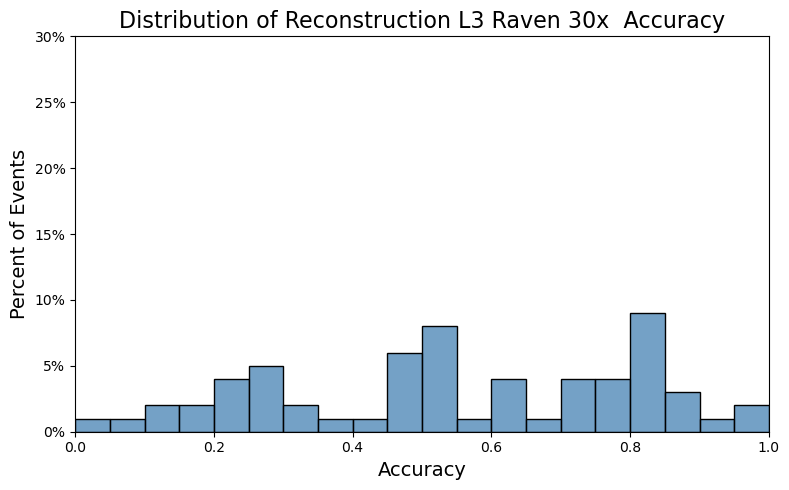

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
plt.figure(figsize=(8,5))
sns.histplot(
    df_acc_assigned["ordered_best_overlap_pct"],
    bins=20, 
    binrange=(0, 1),
    kde=False, 
    shrink=1,
    color="steelblue"
)

plt.xlabel("Accuracy", fontsize=14)
plt.ylabel("Number of Events", fontsize=14)
plt.title("Distribution of Reconstruction L3 Raven 30x  Accuracy", fontsize=16)
ax = plt.gca()

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{int(x)}%")
)
ax.set_ylim(0, 30)
ax.set_xlim(0, 1.0)
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
plt.ylabel("Percent of Events", fontsize=14)
plt.tight_layout()
plt.savefig("Accuracy_L3S30xhpv.pdf")
plt.show()



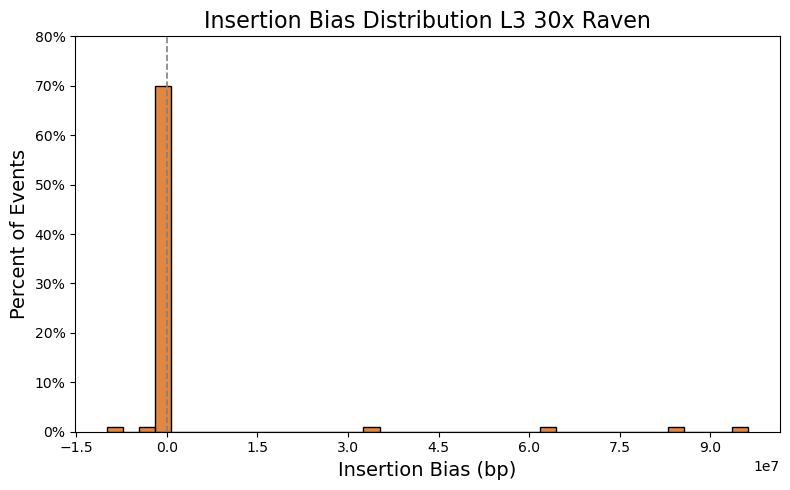

In [30]:
import matplotlib.ticker as mticker
plt.figure(figsize=(8,5))

sns.histplot(
    df_bias["bias_bp"],
    bins=40,
    kde=False,
    color="#d95f02"  
)

plt.axvline(0, color="gray", linestyle="--", linewidth=1.2)
plt.xlabel("Insertion Bias (bp)", fontsize=14)
plt.ylabel("Percent of Events", fontsize=14)
plt.title("Insertion Bias Distribution L3 30x Raven", fontsize=16)

# plt.xlim(df_bias["bias_bp"].min()*1.1, df_bias["bias_bp"].max()*1.1)

ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{int(x)}%")
)
ax.set_ylim(0,80)

xmin = df_bias["bias_bp"].min()
xmax = df_bias["bias_bp"].max()

if xmin == xmax:
    delta = max(1, abs(xmin) * 0.1)
    plt.xlim(xmin - delta, xmax + delta)
else:
    buffer = (xmax - xmin) * 0.05
    plt.xlim(xmin - buffer, xmax + buffer)
    
plt.tight_layout()
plt.savefig("Bias_L3S30xhpv.pdf")
plt.show()
